# House Price Prediction — Ames Housing Dataset
### Comparing Linear Regression, Random Forest and Gradient Boosting 
### to predict house prices using the Ames Housing dataset from Kaggle.
### **Best R2 Score achieved: 0.905 (Gradient Boosting)**

In [1]:
# Importing libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Reading .csv file 
housing_df = pd.read_csv('train.csv')

In [3]:
# DataFrame
housing_df

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1455,1456,60,RL,62.0,7917,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,8,2007,WD,Normal,175000
1456,1457,20,RL,85.0,13175,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,MnPrv,NaN,0,2,2010,WD,Normal,210000
1457,1458,70,RL,66.0,9042,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,GdPrv,Shed,2500,5,2010,WD,Normal,266500
1458,1459,20,RL,68.0,9717,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,4,2010,WD,Normal,142125


## Data Preprocessing
### Handling missing values, dropping high-missing columns, 
### encoding categorical variables and scaling features.

In [4]:
# Looking for Null values in DataFrame

# print(housing_df.shape)
# print(housing_df.isnull().sum())
# print(housing_df.dtypes)

# To find sum of Null Values
missing = housing_df.isnull().sum()
missing = missing[missing > 0].sort_values(ascending = False)
print(missing)

PoolQC          1453
MiscFeature     1406
Alley           1369
Fence           1179
MasVnrType       872
FireplaceQu      690
LotFrontage      259
GarageType        81
GarageYrBlt       81
GarageFinish      81
GarageQual        81
GarageCond        81
BsmtFinType2      38
BsmtExposure      38
BsmtFinType1      37
BsmtCond          37
BsmtQual          37
MasVnrArea         8
Electrical         1
dtype: int64


In [5]:
# To find percentage of Null values in columns (above 40-50% -- Drop Columns)
missing_percent = (housing_df.isnull().sum() / len(housing_df)) * 100
missing_percent = missing_percent[missing_percent > 0].sort_values(ascending=False)
print(missing_percent)

PoolQC          99.520548
MiscFeature     96.301370
Alley           93.767123
Fence           80.753425
MasVnrType      59.726027
FireplaceQu     47.260274
LotFrontage     17.739726
GarageType       5.547945
GarageYrBlt      5.547945
GarageFinish     5.547945
GarageQual       5.547945
GarageCond       5.547945
BsmtFinType2     2.602740
BsmtExposure     2.602740
BsmtFinType1     2.534247
BsmtCond         2.534247
BsmtQual         2.534247
MasVnrArea       0.547945
Electrical       0.068493
dtype: float64


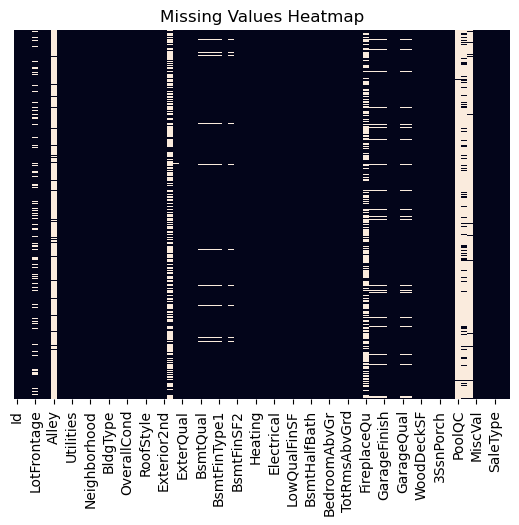

In [6]:
# Displaying empty values using a heatmap (white represents empty)
sns.heatmap(housing_df.isnull(), cbar=False, yticklabels=False)
plt.title('Missing Values Heatmap')
plt.show()

In [7]:
# Droping Null columns
housing_df.drop(columns=['PoolQC', 'MiscFeature', 'Alley', 'Fence', 'MasVnrType', 'FireplaceQu'], inplace=True)

In [8]:
# Refined DataFrame with no Null columns above 40%
housing_df

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,LotShape,LandContour,Utilities,LotConfig,...,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,Reg,Lvl,AllPub,Inside,...,0,0,0,0,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,Reg,Lvl,AllPub,FR2,...,0,0,0,0,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,IR1,Lvl,AllPub,Inside,...,0,0,0,0,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,IR1,Lvl,AllPub,Corner,...,272,0,0,0,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,IR1,Lvl,AllPub,FR2,...,0,0,0,0,0,12,2008,WD,Normal,250000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1455,1456,60,RL,62.0,7917,Pave,Reg,Lvl,AllPub,Inside,...,0,0,0,0,0,8,2007,WD,Normal,175000
1456,1457,20,RL,85.0,13175,Pave,Reg,Lvl,AllPub,Inside,...,0,0,0,0,0,2,2010,WD,Normal,210000
1457,1458,70,RL,66.0,9042,Pave,Reg,Lvl,AllPub,Inside,...,0,0,0,0,2500,5,2010,WD,Normal,266500
1458,1459,20,RL,68.0,9717,Pave,Reg,Lvl,AllPub,Inside,...,112,0,0,0,0,4,2010,WD,Normal,142125


In [9]:
missing_percent = (housing_df.isnull().sum() / len(housing_df)) * 100
missing_percent = missing_percent[missing_percent > 0].sort_values(ascending=False)
print(missing_percent)

LotFrontage     17.739726
GarageType       5.547945
GarageYrBlt      5.547945
GarageFinish     5.547945
GarageQual       5.547945
GarageCond       5.547945
BsmtExposure     2.602740
BsmtFinType2     2.602740
BsmtQual         2.534247
BsmtCond         2.534247
BsmtFinType1     2.534247
MasVnrArea       0.547945
Electrical       0.068493
dtype: float64


In [10]:
# Filling Empty columns(NaN) with median
housing_df.fillna(housing_df.median(numeric_only = True), inplace = True)

In [11]:
# Filling Empty columns(NaN) with median and mode
for col in housing_df.select_dtypes(include='object').columns:
    housing_df[col] = housing_df[col].fillna(housing_df[col].mode()[0])

In [12]:
# Final check
housing_df.isnull().sum().sum()

np.int64(0)

In [13]:
# New Shape of DataFrame after filling with mode 
housing_df = pd.get_dummies(housing_df, drop_first=True)
print(housing_df.shape)

(1460, 231)


## Model Training and Evaluation
### Training three regression models and comparing performance 
### using R2 score and residual analysis.

In [14]:
# Splitting data in x and y
x = housing_df.drop('SalePrice', axis = 1)
y = housing_df['SalePrice']

In [15]:
''' 
Importing train_test_split from sklearn.model_selection 
to split x and y data for training and testing
'''
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.30, random_state=42)

In [16]:
''' 
Importing StandardScaler from sklearn.preprocessing to standarize scaling
'''
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

In [17]:
# Transforming and fitting x_train for training, tranforming x_test for testing on unseen data
x_train = scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)

In [18]:
''' 
Importing LinearRegression from sklearn.linear_model
and cross_val_score from skelearn.model_selection
'''
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import cross_val_score

regression = LinearRegression().fit(x_train, y_train)
mse = cross_val_score(regression, x_train, y_train, scoring='neg_mean_squared_error', cv=10)

In [19]:
# Mean squared error
mse

array([-1.17759898e+09, -3.85405932e+08, -8.43530079e+09, -4.56432441e+09,
       -9.80637073e+08, -2.09361018e+09, -5.86893657e+08, -4.47455821e+08,
       -3.02717069e+09, -4.58805805e+09])

In [20]:
np.mean(mse)

np.float64(-2628645557.896241)

In [21]:
# Predicting using LinearRegression
reg_pred = regression.predict(x_test)

In [22]:
reg_pred

array([ 156185.34652504,  358403.64210184,   88749.48913622,
        178795.27719829,  330445.66415401,   69777.50392183,
        230586.19108965,  147657.28346536,   58554.63157272,
        146902.10205552,  149823.51840743,  102257.35060526,
         85755.2456887 ,  221840.68302697,  174499.69877382,
        131148.67149533,  189492.88656381,  132103.70830603,
        126399.11314855,  217977.00225997,  165527.96405475,
        208827.49576585,  170938.28218081,  131190.29115255,
        202475.62867809,  133196.42702513,  196361.25181798,
        107568.52209933,  176609.16080546,  199621.87022109,
        155993.9961167 ,  277479.44375161,  236585.98356388,
        107908.92346225,  236638.31088895,  149662.09517077,
        140407.76608562,  199810.18685932,  309866.12456209,
        109549.21479246,  114755.23778382,  225266.79633539,
        104763.63168415,  371120.66808431,  136442.53826962,
        139069.25965297,   98380.6636916 ,  140858.35578661,
        413307.10690642,

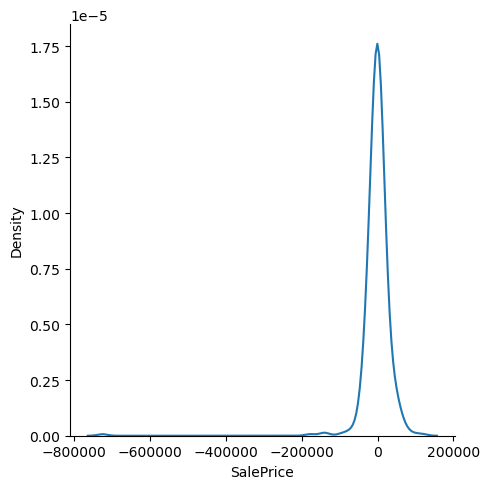

In [23]:
sns.displot(reg_pred-y_test, kind='kde')
plt.show()

In [24]:
# Importing r2_score from sklearn.metrics
from sklearn.metrics import r2_score

score = r2_score(y_test, reg_pred)

In [25]:
# Score of prediction using LinearRegression
score

0.7268722780484842

In [26]:
'''
Importing RandomForestRegressor from sklearn.ensemble
'''
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import cross_val_score

rfr = RandomForestRegressor(n_estimators=100, random_state=42)
rfr.fit(x_train, y_train)

# Cross validation on training data
rfr_mse = cross_val_score(rfr, x_train, y_train, scoring='neg_mean_squared_error', cv=10)

In [27]:
rfr_mse

array([-1.40158775e+09, -5.44921757e+08, -1.82426519e+09, -2.27214658e+09,
       -1.25585176e+09, -7.36584018e+08, -7.97612029e+08, -5.93571400e+08,
       -7.14043455e+08, -6.24238097e+08])

In [28]:
np.mean(rfr_mse)

np.float64(-1076482203.6932423)

In [29]:
# Predicting using RandomForestRegressor
rfr_pred = rfr.predict(x_test)

In [30]:
rfr_pred

array([139497.75, 308982.52, 119260.  , 148810.34, 320048.01,  81161.5 ,
       205283.65, 151728.24,  83293.  , 131061.34, 157760.65, 120473.  ,
       107349.5 , 205078.82, 179371.4 , 129546.  , 194075.55, 134298.  ,
       115632.  , 205785.67, 167384.  , 237109.36, 173813.6 , 118997.  ,
       198581.73, 166946.14, 183640.48, 105682.5 , 179076.5 , 196351.7 ,
       121745.56, 255112.14, 171663.03, 110403.  , 255868.08, 149067.  ,
       132514.69, 201958.9 , 301206.38, 110742.  , 120551.5 , 233447.27,
       121524.75, 365822.17, 137492.6 , 135872.14, 117662.5 , 128537.6 ,
       363832.17, 142623.61, 119628.5 , 193616.28, 121210.8 , 349122.97,
       140236.9 , 241957.65, 196572.9 , 149539.5 , 145803.64, 111719.5 ,
        76202.5 , 145495.  , 303336.22, 284533.24, 286054.49, 203540.19,
       113675.87, 306386.78, 116987.25, 161912.2 , 131905.31, 129344.05,
       110695.  ,  94283.54, 450424.15, 171601.39, 306421.47, 296248.16,
       137691.  , 125195.5 , 101022.5 , 103427.5 , 

In [31]:
rfr_score = r2_score(y_test, rfr_pred)

In [32]:
# Score of prediction using RandomForestRegressor
rfr_score

0.8946800977813667

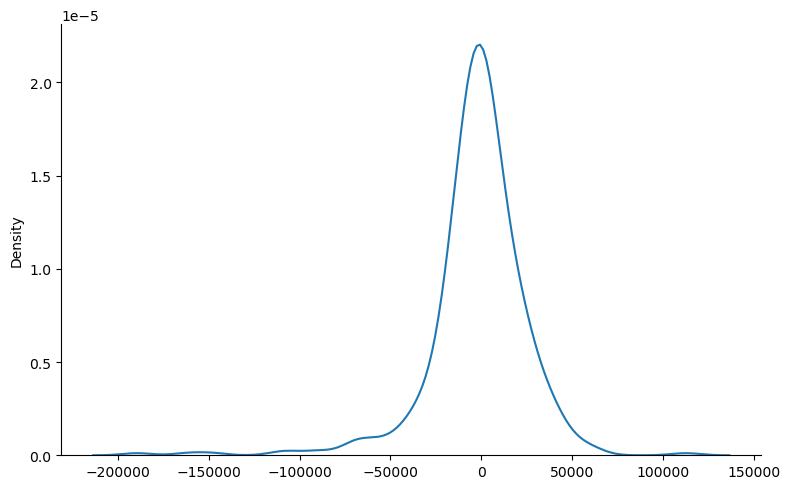

In [33]:
sns.displot(rfr_pred-y_test.values, kind = 'kde', height=5, aspect=1.6)
plt.show()

In [34]:
''' 
Importing GradientBoostingRegressor from sklearn.ensemble
'''
from sklearn.ensemble import GradientBoostingRegressor

gb_model = GradientBoostingRegressor(n_estimators=100, random_state=42)
gb_model.fit(x_train, y_train)

gb_mse = cross_val_score(gb_model, x_train, y_train, scoring = 'neg_mean_squared_error', cv = 10)

In [35]:
# Predicting data using GradientBoostingRegressor
gb_pred = gb_model.predict(x_test)

In [36]:
gb_pred

array([149694.10309017, 328279.28385841, 123333.76611767, 148542.18971796,
       335841.4962209 ,  79986.76459799, 221366.8955928 , 144723.54244195,
        79986.76459799, 133966.30691099, 162317.1357767 , 127348.5300853 ,
       122874.60620468, 198633.72318925, 173143.26849189, 133205.51776072,
       196779.70749421, 138132.68985332, 117257.87167778, 210257.62858626,
       191322.04259271, 220235.85232461, 169451.54973458, 130103.05182415,
       200135.21901974, 168851.46050212, 196487.0162621 , 116558.42892464,
       169350.76324758, 185450.45850923, 120982.55981025, 256097.35116414,
       225264.30314676, 115832.95581293, 256670.33618231, 154133.04052711,
       137793.46622329, 209648.77454143, 318360.94426952, 106107.76166694,
       126850.9342629 , 247239.58298178, 119463.56949638, 364206.9700486 ,
       125152.03827586, 129054.95772918, 117506.76677182, 129247.37728251,
       431661.15601768, 129316.02538604, 122352.25483157, 196315.06854485,
       112317.66943061, 3

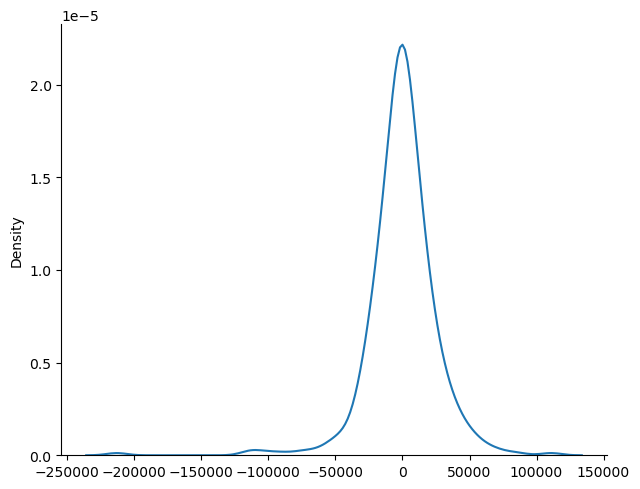

In [37]:
sns.displot(gb_pred - y_test.values, kind = 'kde', height = 5, aspect = 1.3)
plt.show()

In [38]:
# Score of prediction using GradientBoostingRegressor
gb_score = r2_score(y_test, gb_pred)

In [39]:
gb_score

0.9053484378961024

## Results Summary

Comparing all three regression models trained on the Ames Housing Dataset:

| Model | R2 Score |
|---|---|
| Linear Regression | 0.727 |
| Random Forest | 0.895 |
| Gradient Boosting | 0.905 |

**Gradient Boosting** achieved the best performance with an R2 score of **0.905**, meaning the model explains 90.5% of the variance in house prices.

Linear Regression produced a negative price prediction for one house — a known limitation of linear models when extrapolating beyond training data. Tree based models like Random Forest and Gradient Boosting avoid this by predicting only within the range of values seen during training.